In [1]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from tqdm import tqdm

In [4]:
y, sr = librosa.load('datasets/angry/03-01-05-01-01-01-01_fixed_fixed.wav', sr=16000)

In [5]:
y

array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
        0.0000000e+00, -3.0517578e-05,  0.0000000e+00],
      shape=(61929,), dtype=float32)

In [8]:
mel = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_fft=512,
            # hop_length=HOP_LENGTH,
            n_mels=128
        )
mel_db = librosa.power_to_db(mel, ref=np.max)


In [31]:
mfcc = librosa.feature.mfcc(
        y=y,
        sr=16000,
        n_mfcc=512,
        n_fft=512,
        hop_length=512
    )
# Normalize
mfcc = (mfcc - np.mean(mfcc)) / (np.std(mfcc) + 1e-6)

# Remove energy coefficient
mfcc = mfcc[1:, :]


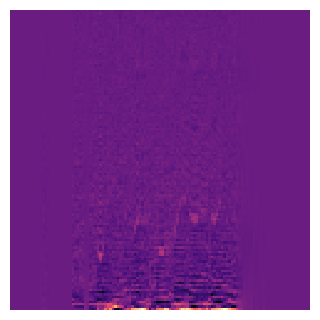

In [35]:
plt.figure(figsize=(300 / 100, 300 / 100), dpi=100)
plt.axes([0, 0, 1, 1])
librosa.display.specshow(mfcc,
    sr=16000,
    hop_length=512,
    cmap='magma',
    # vmin=-3,
    # vmax=3
    )
# librosa.display.specshow(mfcc,)
plt.axis('off')
plt.show()

